In [ ]:
# --- Upward/Downward Spike Detection with Dynamic Threshold ---
import pandas as pd
import numpy as np

def classify_spikes_dynamic(price_series, quantile=0.98):
    price_diff = price_series.diff()
    threshold_up = price_diff.quantile(quantile)
    threshold_down = price_diff.quantile(1 - quantile)
    upward_spike = (price_diff > threshold_up)
    downward_spike = (price_diff < threshold_down)
    return upward_spike, downward_spike

# Example usage:
# up_spike, down_spike, thr_up, thr_down = classify_spikes_dynamic(df['close'], quantile=0.98)
# df['upward_spike'] = up_spike
# df['downward_spike'] = down_spike
# print(f"Upward threshold: {thr_up}, Downward threshold: {thr_down}")


# Spike Hunter algorithm

Automated Candlestick Spike Pattern Labeling for Cryptocurrency Assets

In [23]:
%pip install pandas numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Training and evaluation on a single symbol

[LoadBundle] Loaded bundle from ../checkpoints/spikehunter_model_v2.pkl
[HeikinAshi] Applied smoothing on 400 rows.
[AutoCalibrate] volume_cluster_min_ratio 2.000 -> 3.901 (q=0.985)
[AutoCalibrate] price_break_base_threshold 0.0450 -> 0.0450 (q=0.8)
[AutoCalibrate] Dynamic price quantile logic will still adapt above calibrated floor.
[Cooldown] Suppressed 1 labels
{'timestamp': Timestamp('2025-10-11 09:45:00'), 'close': 0.0030567499999999996, 'label': 0, 'label_pre': 0, 'early_proba_aug_flag': 0, 'is_final_spike': False, 'is_aug_only': False, 'is_suppressed': False, 'signal_type': 'None'}


/var/folders/jf/bv5tm1xj0gl2z7_bb3q05rgm0000gn/T/ipykernel_9771/538438435.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flag = base_flag & (~base_flag.shift(-1).fillna(False))


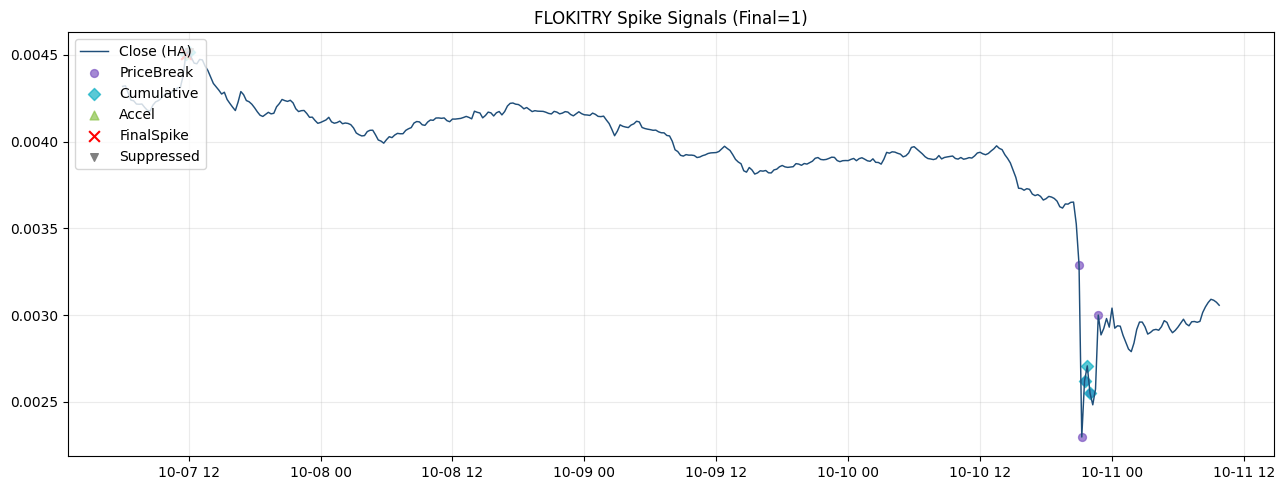

In [ ]:
import pandas as pd
import numpy as np
import requests
import joblib
from typing import Optional

try:
    import matplotlib.pyplot as plt  # type: ignore

    _MATPLOT_OK = True
except Exception:  # pragma: no cover
    _MATPLOT_OK = False

# ----------------- External Data Fetch Helper ----------------- #


def fetch_binance_klines(
    symbol: str, interval: str = "15m", limit: int = 500, end_time: Optional[int] = None
) -> pd.DataFrame:
    """Fetch klines from Binance REST API and return a standardized DataFrame.
    Columns: timestamp, open, high, low, close, volume, quote_asset_volume, taker_base, taker_quote, number_of_trades
    """
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    if end_time:
        params["endTime"] = end_time
    resp = requests.get(url, params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    if not data:
        raise RuntimeError("Empty response from Binance")
    df = pd.DataFrame(
        data,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "quote_asset_volume",
            "number_of_trades",
            "taker_base",
            "taker_quote",
            "ignore",
        ],
    )
    num_cols = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "number_of_trades",
        "taker_base",
        "taker_quote",
    ]
    df[num_cols] = df[num_cols].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    return (
        df[
            [
                "timestamp",
                "open",
                "high",
                "low",
                "close",
                "volume",
                "quote_asset_volume",
                "taker_base",
                "taker_quote",
                "number_of_trades",
            ]
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )


class SpikeHunterV2:  # Production version with added compound/acceleration detection + optional raw price break
    REQUIRED_BASE_FEATURES = [
        "price_change",
        "price_change_abs",
        "body_size_pct",
        "upper_wick_ratio",
        "lower_wick_ratio",
        "is_bullish",
        "close_open_ratio",
        "price_zscore",
        "volume_ratio",
        "volume_zscore",
        "momentum_3",
        "momentum_5",
        "range_pct",
        "close_to_high",
        "close_to_low",
        "taker_buy_ratio",
        "trades_ratio",
        "trades_zscore",
        "quote_volume_ratio",
    ]
    EARLY_FEATURES = [
        "std_ratio_8_20",
        "vol_ratio_slope_3",
        "vol_ratio_accel",
        "trades_ratio_slope_3",
        "quote_vol_ratio_slope_3",
        "pc_1",
        "pc_2c",
        "pc_3c",
        "pc_pos_count_5",
        "pc_abs_sum_5",
        "taker_buy_ratio",
        "taker_buy_ratio_slope_5",
        "body_size_pct_z",
        "vol_compression_flag",
        "volume_ratio",
        "price_zscore",
    ]

    def __init__(
        self,
        symbol: str,
        bundle_path: str,
        df: Optional[pd.DataFrame],
    ):
        """Initialize production SpikeHunterV2.
        Enhancements: auto calibration, compound & acceleration flags, optional raw-based price break, flexible cluster labeling.
        """
        self.symbol = symbol
        self.df: pd.DataFrame = df
        self.keep_original_ohlc = True  # always keep raw_* copies
        self.bundle = self.load_bundle(bundle_path)
        self.thresholds = self.bundle.get("thresholds", {})
        self.models = self.bundle.get("models", {})
        # Core thresholds
        self.volume_cluster_min_ratio = self.thresholds.get(
            "volume_cluster_min_ratio", 2.0
        )
        self.volume_cluster_window = self.thresholds.get("volume_cluster_window", 8)
        self.volume_cluster_min_count = self.thresholds.get(
            "volume_cluster_min_count", 2
        )
        self.volume_cluster_label_mode = self.thresholds.get(
            "volume_cluster_label_mode", "last"
        ).lower()  # now supports: last, all, first
        self.price_break_base_threshold = self.thresholds.get(
            "price_break_base_threshold", 0.05
        )
        self.price_break_dynamic_q = self.thresholds.get("price_break_dynamic_q", 0.90)
        self.price_break_use_dynamic = self.thresholds.get(
            "price_break_use_dynamic", True
        )
        self.price_break_auto_tune = self.thresholds.get("price_break_auto_tune", False)
        self.price_break_target_rate = self.thresholds.get(
            "price_break_target_rate", 0.02
        )
        self.price_break_min_quantile = self.thresholds.get(
            "price_break_min_quantile", 0.75
        )
        self.price_break_max_quantile = self.thresholds.get(
            "price_break_max_quantile", 0.985
        )
        self.price_break_smoothing = self.thresholds.get("price_break_smoothing", 0.5)
        self.price_break_auto_lookback = self.thresholds.get(
            "price_break_auto_lookback", 180
        )
        self.use_raw_price_break = self.thresholds.get("use_raw_price_break", False)
        # New compound / acceleration thresholds
        self.cumulative_price_window = self.thresholds.get("cumulative_price_window", 3)
        self.cumulative_price_threshold = self.thresholds.get(
            "cumulative_price_threshold", 0.035
        )  # 3.5% cumulative
        self.accel_volume_deriv_window = self.thresholds.get(
            "accel_volume_deriv_window", 3
        )
        self.accel_volume_deriv_min = self.thresholds.get("accel_volume_deriv_min", 0.8)
        self.accel_price_change_min = self.thresholds.get(
            "accel_price_change_min", 0.02
        )
        # Early proba
        self.early_proba_threshold = self.thresholds.get("early_proba_threshold", 0.45)
        self.early_proba_min_slope = self.thresholds.get("early_proba_min_slope", 0.05)
        self.early_proba_require_volume = self.thresholds.get(
            "early_proba_require_volume", 1.0
        )
        self.require_both_patterns = self.thresholds.get("require_both_patterns", False)
        self.post_spike_cooldown_bars = self.thresholds.get(
            "post_spike_cooldown_bars", 0
        )
        self.require_bullish_spike = self.thresholds.get("require_bullish_spike", True)
        self.body_size_pct_min = self.thresholds.get("body_size_pct_min", 0.0)
        self.lock_thresholds = bool(self.thresholds.get("lock_thresholds", False))
        # Models
        self.current_clf = self.models.get("current_classifier")
        self.early_clf = self.models.get("lead_classifier")
        self.early_proba_augment = self.bundle.get("metadata", {}).get(
            "early_proba_augment", True
        )
        self.early_proba_slope_lookback = 3
        self._auto_calibrated = False

        if not self.df.empty:
            self.apply_heikin_ashi()
            self.compute_base_features()
            self.auto_calibrate()

    def apply_heikin_ashi(self):
        if self.df.empty:
            return
        required = {"open", "high", "low", "close"}
        df = self.df
        if not required.issubset(df.columns):
            raise ValueError("DataFrame missing required OHLC columns for Heikin Ashi.")
        df = df.copy().sort_values("timestamp").reset_index(drop=True)
        if self.keep_original_ohlc:
            for c in ["open", "high", "low", "close"]:
                raw_col = f"raw_{c}"
                if raw_col not in df.columns:
                    df[raw_col] = df[c]
        ha_close = (df["open"] + df["high"] + df["low"] + df["close"]) / 4.0
        ha_open = ha_close.copy()
        ha_open.iloc[0] = (df.loc[0, "open"] + df.loc[0, "close"]) / 2.0
        for i in range(1, len(df)):
            ha_open.iloc[i] = (ha_open.iloc[i - 1] + ha_close.iloc[i - 1]) / 2.0
        ha_high = pd.concat([df["high"], ha_open, ha_close], axis=1).max(axis=1)
        ha_low = pd.concat([df["low"], ha_open, ha_close], axis=1).min(axis=1)
        df["open"] = ha_open
        df["high"] = ha_high
        df["low"] = ha_low
        df["close"] = ha_close
        df["ha_trend_bull"] = (df["close"] >= df["open"]).astype(int)
        df["ha_body"] = (df["close"] - df["open"]).abs()
        self.df = df
        print(f"[HeikinAshi] Applied smoothing on {len(self.df)} rows.")

    # -------------- Auto Calibration -------------- #
    def auto_calibrate(
        self,
        volume_quantile: float = 0.985,
        price_base_floor_quantile: float = 0.80,
        min_volume_ratio: float = 1.3,
        min_price_abs_floor: float = 0.02,
        verbose: bool = True,
    ):
        if self._auto_calibrated:
            if verbose:
                print("[AutoCalibrate] Already calibrated; skipping.")
            return
        if len(self.df) < 60:
            if verbose:
                print(
                    "[AutoCalibrate] Not enough data (<60 rows); skipping calibration."
                )
            return
        vols = self.df["volume_ratio"].dropna()
        pcs = self.df["price_change_abs"].dropna()
        if vols.empty or pcs.empty:
            if verbose:
                print("[AutoCalibrate] Missing distribution data; skipping.")
            return
        old_vol_thr = self.volume_cluster_min_ratio
        old_price_floor = self.price_break_base_threshold
        new_vol_thr = float(max(min_volume_ratio, np.quantile(vols, volume_quantile)))
        new_price_floor = float(
            max(min_price_abs_floor, np.quantile(pcs, price_base_floor_quantile))
        )
        self.volume_cluster_min_ratio = new_vol_thr
        self.price_break_base_threshold = max(old_price_floor, new_price_floor)
        self._auto_calibrated = True
        if verbose:
            print(
                f"[AutoCalibrate] volume_cluster_min_ratio {old_vol_thr:.3f} -> {self.volume_cluster_min_ratio:.3f} (q={volume_quantile})"
            )
            print(
                f"[AutoCalibrate] price_break_base_threshold {old_price_floor:.4f} -> {self.price_break_base_threshold:.4f} (q={price_base_floor_quantile})"
            )
            if self.price_break_use_dynamic:
                print(
                    "[AutoCalibrate] Dynamic price quantile logic will still adapt above calibrated floor."
                )

    # -------------- Bundle -------------- #
    def load_bundle(self, path: str):
        try:
            bundle = joblib.load(path)
            print(f"[LoadBundle] Loaded bundle from {path}")
            return bundle
        except Exception as e:
            raise RuntimeError(f"Failed to load bundle: {e}")

    # -------------- Feature Engineering -------------- #
    def compute_base_features(self, window: int = 12):
        if self.df.empty:
            return
        df = self.df.sort_values("timestamp").reset_index(drop=True).copy()
        eff = window
        # Price changes (HA based) + raw variant for optional raw price break
        df["price_change"] = df["close"].pct_change()
        df["price_change_abs"] = df["price_change"].abs()
        if "raw_close" in df.columns:
            df["raw_price_change"] = df["raw_close"].pct_change()
            df["raw_price_change_abs"] = df["raw_price_change"].abs()
        df["body_size"] = (df["close"] - df["open"]).abs()
        df["body_size_pct"] = df["body_size"] / (df["open"] + 1e-6)
        df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
        df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
        df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
        df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
        df["total_range"] = df["high"] - df["low"]
        df["range_pct"] = df["total_range"] / (df["open"] + 1e-6)
        df["is_bullish"] = (df["close"] > df["open"]).astype(int)
        df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)
        df["price_ma"] = df["close"].rolling(eff).mean()
        df["price_std"] = df["close"].rolling(eff).std()
        df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)
        df["volume_ma"] = df["volume"].rolling(eff).mean()
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
        df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (
            df["volume"].rolling(eff).std() + 1e-6
        )
        df["quote_volume_ma"] = df["quote_asset_volume"].rolling(eff).mean()
        df["quote_volume_ratio"] = df["quote_asset_volume"] / (
            df["quote_volume_ma"] + 1e-6
        )
        df["trades_ma"] = df["number_of_trades"].rolling(eff).mean()
        df["trades_ratio"] = df["number_of_trades"] / (df["trades_ma"] + 1e-6)
        df["trades_zscore"] = (df["number_of_trades"] - df["trades_ma"]) / (
            df["number_of_trades"].rolling(eff).std() + 1e-6
        )
        df["momentum_3"] = df["close"].pct_change(3)
        df["momentum_5"] = df["close"].pct_change(5)
        df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
        df["close_to_low"] = (df["close"] - df["low"] + 1e-6) / (df["close"] + 1e-6)
        if "taker_base" in df.columns:
            df["taker_buy_ratio"] = df["taker_base"] / (df["volume"] + 1e-6)
        else:
            df["taker_buy_ratio"] = 0.0
        self.df = df

    def compute_early_features(self):
        df = self.df.copy()
        df["rolling_price_std_8"] = df["close"].rolling(8).std()
        df["rolling_price_std_20"] = df["close"].rolling(20).std()
        df["std_ratio_8_20"] = df["rolling_price_std_8"] / (
            df["rolling_price_std_20"] + 1e-6
        )
        df["vol_ratio_slope_3"] = df["volume_ratio"].diff(3)
        df["vol_ratio_accel"] = df["vol_ratio_slope_3"].diff()
        df["trades_ratio_slope_3"] = df.get("trades_ratio", 0).diff(3)
        df["quote_vol_ratio_slope_3"] = df.get("quote_volume_ratio", 0).diff(3)
        df["pc_1"] = df["price_change"]
        df["pc_2c"] = df["price_change"].rolling(2).sum()
        df["pc_3c"] = df["price_change"].rolling(3).sum()
        df["pc_pos_count_5"] = (df["price_change"] > 0).rolling(5).sum()
        df["pc_abs_sum_5"] = df["price_change_abs"].rolling(5).sum()
        df["taker_buy_ratio"] = df.get("taker_buy_ratio", 0.0)
        df["taker_buy_ratio_slope_5"] = df["taker_buy_ratio"].diff(5)
        df["body_size_pct_ma_10"] = df["body_size_pct"].rolling(10).mean()
        df["body_size_pct_std_10"] = df["body_size_pct"].rolling(10).std()
        df["body_size_pct_z"] = (df["body_size_pct"] - df["body_size_pct_ma_10"]) / (
            df["body_size_pct_std_10"] + 1e-6
        )
        df["vol_compression_flag"] = (
            df["rolling_price_std_8"] < df["rolling_price_std_20"] * 0.6
        ).astype(int)
        self.df = df

    # -------------- Rule Components -------------- #
    def classify_spikes(self, quantile=0.98):
        price_diff = self.df["close"].diff()
        threshold_up = price_diff.quantile(quantile)
        threshold_down = price_diff.quantile(1 - quantile)
        upward_spike = (price_diff > threshold_up)
        downward_spike = (price_diff < threshold_down)
        self.df.dropna(inplace=True)
        self.df.reindex(drop=True, inplace=True)
        return upward_spike, downward_spike

    def volume_cluster_flag(self):
        df = self.df
        cond = df["volume_ratio"] >= self.volume_cluster_min_ratio
        rolling_count = cond.rolling(self.volume_cluster_window, min_periods=1).sum()
        base_flag = (rolling_count >= self.volume_cluster_min_count) & cond
        if self.volume_cluster_label_mode == "last":
            flag = base_flag & (~base_flag.shift(-1).fillna(False))
        elif self.volume_cluster_label_mode == "first":
            flag = base_flag & (~base_flag.shift(1).fillna(False))
        else:  # 'all'
            flag = base_flag
        self.df["volume_cluster_flag"] = flag.astype(int)

    def price_break_flag(self):
        df = self.df
        # Choose source (raw vs HA) for price change absolute
        price_abs_series = (
            df["raw_price_change_abs"]
            if (self.use_raw_price_break and "raw_price_change_abs" in df.columns)
            else df["price_change_abs"]
        )
        if not self.price_break_use_dynamic:
            thr_series = pd.Series(self.price_break_base_threshold, index=df.index)
        else:
            base_dyn = price_abs_series.rolling(60, min_periods=20).quantile(
                self.price_break_dynamic_q
            )
            if self.price_break_auto_tune:
                q_recent = 1.0 - self.price_break_target_rate
                q_recent = np.clip(
                    q_recent,
                    self.price_break_min_quantile,
                    self.price_break_max_quantile,
                )
                adaptive = price_abs_series.rolling(
                    self.price_break_auto_lookback, min_periods=40
                ).apply(lambda x: np.quantile(x, q_recent), raw=False)
                dyn = (
                    self.price_break_smoothing * base_dyn
                    + (1 - self.price_break_smoothing) * adaptive
                )
            else:
                dyn = base_dyn
            thr_series = pd.Series(
                np.maximum(self.price_break_base_threshold, dyn), index=df.index
            ).ffill()
        self.df["price_break_flag"] = (price_abs_series >= thr_series).astype(int)

    def cumulative_price_break_flag(self):
        """Flag if cumulative positive move over a short window exceeds threshold (captures stair-step rallies)."""
        df = self.df
        w = self.cumulative_price_window
        if w <= 1:
            self.df["cumulative_price_break_flag"] = 0
            return
        pos_pc = df["price_change"].clip(lower=0)
        cum_pos = pos_pc.rolling(w).sum()
        # Require at least one elevated volume within window (>= 80% of volume threshold) to reduce noise
        vol_cond = (
            (df["volume_ratio"] >= (self.volume_cluster_min_ratio * 0.8))
            .rolling(w)
            .max()
            .astype(bool)
        )
        flag = (cum_pos >= self.cumulative_price_threshold) & vol_cond
        self.df["cumulative_price_break_flag"] = flag.astype(int)

    def acceleration_flag(self):
        """Detect sharp acceleration: jump in volume ratio derivative AND immediate price expansion."""
        df = self.df
        w = self.accel_volume_deriv_window
        vol_deriv = df["volume_ratio"] - df["volume_ratio"].shift(w)
        price_abs_now = (
            df["price_change_abs"]
            if not self.use_raw_price_break
            else df.get("raw_price_change_abs", df["price_change_abs"])
        )
        flag = (
            (vol_deriv >= self.accel_volume_deriv_min)
            & (price_abs_now >= self.accel_price_change_min)
            & (df["price_change"] > 0)  # ensure upward move
        )
        self.df["accel_spike_flag"] = flag.fillna(False).astype(int)

    def apply_preliminary_label(self):
        self.volume_cluster_flag()
        self.price_break_flag()
        self.cumulative_price_break_flag()
        self.acceleration_flag()
        df = self.df
        # Primary pattern combination
        if self.require_both_patterns:
            base_combo = (
                (df["volume_cluster_flag"] == 1) & (df["price_break_flag"] == 1)
            ).astype(int)
        else:
            base_combo = (
                (df["volume_cluster_flag"] == 1) | (df["price_break_flag"] == 1)
            ).astype(int)
        # Integrate new auxiliary flags (OR)
        aux = (df["cumulative_price_break_flag"] == 1) | (df["accel_spike_flag"] == 1)
        label_pre = (base_combo | aux).astype(int)
        if self.require_bullish_spike:
            label_pre = label_pre & (df["is_bullish"] == 1)
        if self.body_size_pct_min > 0:
            label_pre = label_pre & (df["body_size_pct"] >= self.body_size_pct_min)
        self.df["label_pre"] = label_pre.astype(int)
        self.df["label"] = self.df["label_pre"].copy()

    def compute_early_proba(self):
        if not self.early_proba_augment or self.early_clf is None:
            self.df["early_spike_proba"] = np.nan
            self.df["early_proba_aug_flag"] = 0
            return
        if any(f not in self.df.columns for f in self.EARLY_FEATURES):
            self.compute_early_features()
        feats = self.df[self.EARLY_FEATURES].fillna(0)
        try:
            proba = self.early_clf.predict_proba(feats)[:, 1]
        except Exception:
            proba = np.zeros(len(self.df))
        self.df["early_spike_proba"] = proba
        slope = self.df["early_spike_proba"] - self.df["early_spike_proba"].shift(
            self.early_proba_slope_lookback
        )
        cond = (
            (self.df["early_spike_proba"] >= self.early_proba_threshold)
            & (slope >= self.early_proba_min_slope)
            & (self.df["volume_ratio"] >= self.early_proba_require_volume)
        )
        if self.require_bullish_spike:
            cond &= self.df["is_bullish"] == 1
        if self.body_size_pct_min > 0:
            cond &= self.df["body_size_pct"] >= self.body_size_pct_min
        self.df["early_proba_aug_flag"] = cond.astype(int)
        self.df["label"] = (
            (self.df["label_pre"] == 1) | (self.df["early_proba_aug_flag"] == 1)
        ).astype(int)

    def apply_cooldown(self):
        if self.post_spike_cooldown_bars <= 0:
            self.df["suppressed_label"] = 0
            return
        last_idx = None
        suppressed = 0
        self.df["suppressed_label"] = 0
        for i in self.df.index:
            if self.df.at[i, "label"] == 1:
                if (
                    last_idx is not None
                    and (i - last_idx) <= self.post_spike_cooldown_bars
                ):
                    self.df.at[i, "suppressed_label"] = 1
                    self.df.at[i, "label"] = 0
                    if (
                        self.df.at[i, "early_proba_aug_flag"] == 1
                        and self.df.at[i, "label_pre"] == 0
                    ):
                        self.df.at[i, "early_proba_aug_flag"] = 0
                    suppressed += 1
                else:
                    last_idx = i
        if suppressed:
            print(f"[Cooldown] Suppressed {suppressed} labels")

    # -------------- Public API -------------- #
    def detect(self) -> pd.DataFrame:
        if self.df.empty:
            raise RuntimeError("No data loaded; set df or call refresh().")
        if "ha_trend_bull" not in self.df.columns:
            self.apply_heikin_ashi()
        if "volume_ratio" not in self.df.columns:
            self.compute_base_features()
        if not self._auto_calibrated and not self.lock_thresholds:
            self.auto_calibrate(verbose=True)
        # Recompute base each pass to keep derivative series consistent
        self.compute_base_features()
        self.apply_preliminary_label()
        self.compute_early_proba()
        self.apply_cooldown()
        return self.df

    def latest_signal(self, run_detect: bool = False) -> dict:
        if self.df.empty:
            raise RuntimeError("No data available.")
        if run_detect or "label" not in self.df.columns:
            self.detect()
        row = self.df.iloc[-1]
        is_final = bool(row.get("label", 0) == 1)
        is_aug_only = bool(
            is_final
            and row.get("label_pre", 0) == 0
            and row.get("early_proba_aug_flag", 0) == 1
        )
        is_supp = bool(row.get("suppressed_label", 0) == 1)
        if is_final:
            signal_type = "AugOnly" if is_aug_only else "FinalSpike"
        elif is_supp:
            signal_type = "Suppressed"
        else:
            signal_type = "None"

        upward_spike, downward_spike = self.classify_spikes(threshold=0.02)

        return {
            "timestamp": row.get("timestamp"),
            "close": float(row.get("close", np.nan)),
            "label": int(row.get("label", 0)),
            "label_pre": int(row.get("label_pre", 0)),
            "early_proba_aug_flag": int(row.get("early_proba_aug_flag", 0)),
            "is_final_spike": is_final,
            "is_aug_only": is_aug_only,
            "is_suppressed": is_supp,
            "signal_type": signal_type,
            "upward_spike": bool(upward_spike.iloc[-1]),
            "downward_spike": bool(downward_spike.iloc[-1]),
        }

    def plot_signals(
        self,
        show_aug: bool = True,
        show_suppressed: bool = False,
        show_price_break: bool = True,
        show_cumulative: bool = True,
        show_accel: bool = True,
    ):
        if not _MATPLOT_OK:
            raise ImportError(
                "matplotlib not available. Install matplotlib to use plot_signals()."
            )
        if "label" not in self.df.columns:
            self.detect()
        df = self.df
        plt.figure(figsize=(13, 5))
        plt.plot(
            df["timestamp"],
            df["close"],
            label="Close (HA)",
            linewidth=1.05,
            color="#1f4e79",
        )
        if show_price_break and "price_break_flag" in df.columns:
            pb_idx = df.index[df["price_break_flag"] == 1]
            if len(pb_idx) > 0:
                plt.scatter(
                    df.loc[pb_idx, "timestamp"],
                    df.loc[pb_idx, "close"],
                    c="#7e57c2",
                    s=32,
                    marker="o",
                    alpha=0.7,
                    label="PriceBreak",
                )
        if show_cumulative and "cumulative_price_break_flag" in df.columns:
            cp_idx = df.index[df["cumulative_price_break_flag"] == 1]
            if len(cp_idx) > 0:
                plt.scatter(
                    df.loc[cp_idx, "timestamp"],
                    df.loc[cp_idx, "close"],
                    c="#00acc1",
                    s=38,
                    marker="D",
                    alpha=0.65,
                    label="Cumulative",
                )
        if show_accel and "accel_spike_flag" in df.columns:
            ac_idx = df.index[df["accel_spike_flag"] == 1]
            if len(ac_idx) > 0:
                plt.scatter(
                    df.loc[ac_idx, "timestamp"],
                    df.loc[ac_idx, "close"],
                    c="#8bc34a",
                    s=40,
                    marker="^",
                    alpha=0.7,
                    label="Accel",
                )
        final_idx = df.index[df["label"] == 1]
        if len(final_idx) > 0:
            plt.scatter(
                df.loc[final_idx, "timestamp"],
                df.loc[final_idx, "close"],
                c="red",
                marker="x",
                s=60,
                label="FinalSpike",
            )
        if show_aug and "early_proba_aug_flag" in df.columns:
            aug_only_idx = df.index[
                (df["early_proba_aug_flag"] == 1)
                & (df["label_pre"] == 0)
                & (df["label"] == 1)
            ]
            if len(aug_only_idx) > 0:
                plt.scatter(
                    df.loc[aug_only_idx, "timestamp"],
                    df.loc[aug_only_idx, "close"],
                    c="orange",
                    s=45,
                    label="AugOnly",
                )
        if show_suppressed and "suppressed_label" in df.columns:
            sup_idx = df.index[df["suppressed_label"] == 1]
            if len(sup_idx) > 0:
                plt.scatter(
                    df.loc[sup_idx, "timestamp"],
                    df.loc[sup_idx, "close"],
                    c="gray",
                    s=30,
                    marker="v",
                    label="Suppressed",
                )
        plt.title(f"{self.symbol} Spike Signals (Final={int(df['label'].sum())})")
        plt.legend(loc="upper left")
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


# Example usage (updated with new flags)
raw_df = fetch_binance_klines("FLOKITRY", interval="15m", limit=400)
prod = SpikeHunterV2(
    symbol="FLOKITRY",
    bundle_path="../checkpoints/spikehunter_model_v2.pkl",
    df=raw_df,
)
prod.detect()
print(prod.latest_signal())
prod.plot_signals(
    show_aug=True,
    show_suppressed=True,
    show_price_break=True,
    show_cumulative=True,
    show_accel=True,
)


# Production-Only Minimal Class
 =============================
 This cell overrides the previous SpikeHunterV2 definition with a lightweight
 inference-focused version (no training, no plotting) suitable for production usage.
 Core responsibilities:
   - Load serialized bundle (thresholds + trained models)
   - Fetch (or accept) market data
   - Compute base & early features (only those required for inference)
   - Apply preliminary labeling rules using stored thresholds
   - Run early probability augmentation (if model + flag present)
   - Apply cooldown suppression
   - Provide a detect() method returning a DataFrame with final labels

 Assumptions:
   - Bundle produced by the training notebook and saved at ../checkpoints/spikehunter_model_v2.pkl
   - Rolling windows & feature definitions match training-time logic
   - Only upward (bullish) spikes considered if require_bullish_spike in thresholds


[AutoCalibrate] volume_cluster_min_ratio 2.000 -> 6.756 (q=0.985)
[AutoCalibrate] price_break_base_threshold 0.0500 -> 0.0500 (q=0.8)
[AutoCalibrate] Dynamic price quantile logic will adapt above calibrated floor.
[Example] Latest signal: {'timestamp': Timestamp('2025-10-11 01:00:00'), 'close': 0.03227688800491657, 'label': 0, 'label_pre': 0, 'early_proba_aug_flag': 0, 'volume_cluster_flag': False, 'price_break_flag': False, 'cumulative_price_break_flag': False, 'accel_spike_flag': False, 'is_final_spike': False, 'is_aug_only': False, 'is_suppressed': False, 'signal_type': None, 'signals': []}


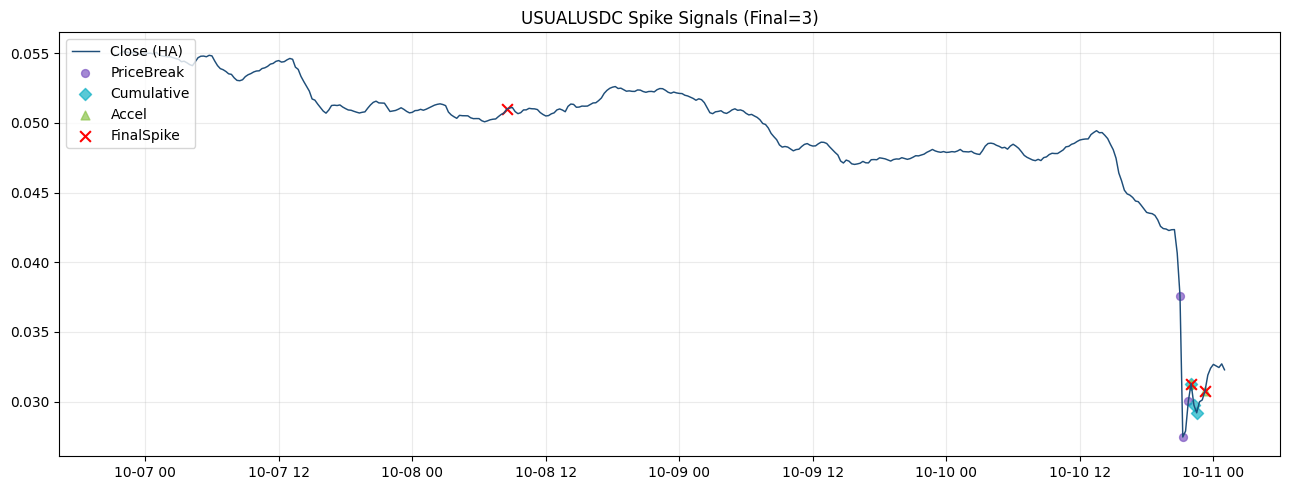

In [31]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from typing import Optional, Union

BASE_REQUIRED = {
    "timestamp",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
}


def _assert_required(df: pd.DataFrame):
    missing = BASE_REQUIRED - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")


class SpikeHunterV2:
    REQUIRED_BASE_FEATURES = [
        "price_change",
        "price_change_abs",
        "body_size_pct",
        "upper_wick_ratio",
        "lower_wick_ratio",
        "is_bullish",
        "close_open_ratio",
        "price_zscore",
        "volume_ratio",
        "volume_zscore",
        "momentum_3",
        "momentum_5",
        "range_pct",
        "close_to_high",
        "close_to_low",
        "taker_buy_ratio",
        "trades_ratio",
        "trades_zscore",
        "quote_volume_ratio",
    ]
    EARLY_FEATURES = [
        "std_ratio_8_20",
        "vol_ratio_slope_3",
        "vol_ratio_accel",
        "trades_ratio_slope_3",
        "quote_vol_ratio_slope_3",
        "pc_1",
        "pc_2c",
        "pc_3c",
        "pc_pos_count_5",
        "pc_abs_sum_5",
        "taker_buy_ratio",
        "taker_buy_ratio_slope_5",
        "body_size_pct_z",
        "vol_compression_flag",
        "volume_ratio",
        "price_zscore",
    ]

    def __init__(
        self,
        symbol: str,
        bundle: Optional[Union[str, dict]] = None,
        df: Optional[pd.DataFrame] = None,
        interval: str = "15m",
        limit: int = 500,
        auto_calibrate: bool = True,
        lock_thresholds: bool = False,
    ):
        """Notebook-friendly constructor.

        Parameters:
          symbol: trading pair symbol
          bundle: path to pkl (joblib) or already loaded dict with 'thresholds' & 'models'
          df: optional preloaded OHLC dataframe (raw)
        """
        self.symbol = symbol
        self.interval = interval
        self.limit = limit
        self.df: pd.DataFrame = pd.DataFrame()
        self.keep_original_ohlc = True
        self._auto_calibrated = False
        # Load / assign bundle
        if bundle is None:
            self.bundle = {"thresholds": {}, "models": {}, "metadata": {}}
        elif isinstance(bundle, str):
            try:
                self.bundle = joblib.load(bundle)
            except Exception as e:
                raise RuntimeError(f"Failed to load bundle: {e}")
        elif isinstance(bundle, dict):
            self.bundle = bundle
        else:
            raise TypeError("bundle must be None, str path, or dict")

        self.thresholds = self.bundle.get("thresholds", {})
        self.models = self.bundle.get("models", {})
        # Thresholds (mirroring production attributes)
        self.volume_cluster_min_ratio = self.thresholds.get(
            "volume_cluster_min_ratio", 2.0
        )
        self.volume_cluster_window = self.thresholds.get("volume_cluster_window", 8)
        self.volume_cluster_min_count = self.thresholds.get(
            "volume_cluster_min_count", 2
        )
        self.volume_cluster_label_mode = self.thresholds.get(
            "volume_cluster_label_mode", "last"
        ).lower()
        self.price_break_base_threshold = self.thresholds.get(
            "price_break_base_threshold", 0.05
        )
        self.price_break_dynamic_q = self.thresholds.get("price_break_dynamic_q", 0.90)
        self.price_break_use_dynamic = self.thresholds.get(
            "price_break_use_dynamic", True
        )
        self.price_break_auto_tune = self.thresholds.get("price_break_auto_tune", False)
        self.price_break_target_rate = self.thresholds.get(
            "price_break_target_rate", 0.02
        )
        self.price_break_min_quantile = self.thresholds.get(
            "price_break_min_quantile", 0.75
        )
        self.price_break_max_quantile = self.thresholds.get(
            "price_break_max_quantile", 0.985
        )
        self.price_break_smoothing = self.thresholds.get("price_break_smoothing", 0.5)
        self.price_break_auto_lookback = self.thresholds.get(
            "price_break_auto_lookback", 180
        )
        self.use_raw_price_break = self.thresholds.get("use_raw_price_break", False)
        self.cumulative_price_window = self.thresholds.get("cumulative_price_window", 3)
        self.cumulative_price_threshold = self.thresholds.get(
            "cumulative_price_threshold", 0.035
        )
        self.accel_volume_deriv_window = self.thresholds.get(
            "accel_volume_deriv_window", 3
        )
        self.accel_volume_deriv_min = self.thresholds.get("accel_volume_deriv_min", 0.8)
        self.accel_price_change_min = self.thresholds.get(
            "accel_price_change_min", 0.02
        )
        self.early_proba_threshold = self.thresholds.get("early_proba_threshold", 0.45)
        self.early_proba_min_slope = self.thresholds.get("early_proba_min_slope", 0.05)
        self.early_proba_require_volume = self.thresholds.get(
            "early_proba_require_volume", 1.0
        )
        self.require_both_patterns = self.thresholds.get("require_both_patterns", False)
        self.post_spike_cooldown_bars = self.thresholds.get(
            "post_spike_cooldown_bars", 0
        )
        self.require_bullish_spike = self.thresholds.get("require_bullish_spike", True)
        self.body_size_pct_min = self.thresholds.get("body_size_pct_min", 0.0)
        self.lock_thresholds = lock_thresholds or bool(
            self.thresholds.get("lock_thresholds", False)
        )
        self.current_clf = self.models.get("current_classifier")
        self.early_clf = self.models.get("lead_classifier")
        self.early_proba_augment = self.bundle.get("metadata", {}).get(
            "early_proba_augment", True
        )
        self.early_proba_slope_lookback = 3

        if df is not None and not df.empty:
            _assert_required(df)
            self.df = df.sort_values("timestamp").reset_index(drop=True).copy()
            self.apply_heikin_ashi()
            self.compute_base_features()
            if auto_calibrate and not self.lock_thresholds:
                self.auto_calibrate(verbose=True)

    def cleanup(self):
        self.df.dropna(inplace=True)
        self.df.reset_index(drop=True, inplace=True)

    # -------- Heikin Ashi (mirrors production logic) -------- #
    def apply_heikin_ashi(self):
        if self.df.empty:
            return

        # Validate & coerce using the new type guard helper.
        work = self.df.reset_index(drop=True).copy()

        # Compute HA_Close from ORIGINAL OHLC (still intact in 'work').
        # Ensure numeric dtypes (API feeds sometimes deliver strings)
        ohlc_cols = ["open", "high", "low", "close"]
        for c in ohlc_cols:
            # Only attempt conversion if dtype is not already numeric
            if not pd.api.types.is_numeric_dtype(work[c]):
                work.loc[:, c] = pd.to_numeric(work[c], errors="coerce")

        if work[ohlc_cols].isna().any().any():
            # Drop rows that became NaN after coercion (invalid numeric data)
            work = work.dropna(subset=ohlc_cols).reset_index(drop=True)
            if work.empty:
                raise ValueError("All OHLC rows became NaN after numeric coercion.")

        ha_close = (work["open"] + work["high"] + work["low"] + work["close"]) / 4.0

        # Seed HA_Open with original O & C (not HA close).
        ha_open = ha_close.copy()
        ha_open.iloc[0] = (work["open"].iloc[0] + work["close"].iloc[0]) / 2.0
        for i in range(1, len(work)):
            ha_open.iloc[i] = (ha_open.iloc[i - 1] + ha_close.iloc[i - 1]) / 2.0

        # High / Low derived from max/min of (raw high/low, ha_open, ha_close)
        ha_high = pd.concat([work["high"], ha_open, ha_close], axis=1).max(axis=1)
        ha_low = pd.concat([work["low"], ha_open, ha_close], axis=1).min(axis=1)

        # Assign transformed values.
        work.loc[:, "open"] = ha_open
        work.loc[:, "high"] = ha_high
        work.loc[:, "low"] = ha_low
        work.loc[:, "close"] = ha_close
        self.df = work

    # -------- Auto Calibration -------- #
    def auto_calibrate(
        self,
        volume_quantile: float = 0.985,
        price_base_floor_quantile: float = 0.80,
        min_volume_ratio: float = 1.3,
        min_price_abs_floor: float = 0.02,
        verbose: bool = True,
    ):
        if self._auto_calibrated:
            if verbose:
                print("[AutoCalibrate] Already calibrated; skipping.")
            return
        if len(self.df) < 60:
            if verbose:
                print(
                    "[AutoCalibrate] Not enough data (<60 rows); skipping calibration."
                )
            return
        vols = self.df.get("volume_ratio", pd.Series(dtype=float)).dropna()
        pcs = self.df.get("price_change_abs", pd.Series(dtype=float)).dropna()
        if vols.empty or pcs.empty:
            if verbose:
                print("[AutoCalibrate] Missing distribution data; skipping.")
            return
        old_vol_thr = self.volume_cluster_min_ratio
        old_price_floor = self.price_break_base_threshold
        new_vol_thr = float(max(min_volume_ratio, np.quantile(vols, volume_quantile)))
        new_price_floor = float(
            max(min_price_abs_floor, np.quantile(pcs, price_base_floor_quantile))
        )
        self.volume_cluster_min_ratio = new_vol_thr
        self.price_break_base_threshold = max(old_price_floor, new_price_floor)
        self._auto_calibrated = True
        if verbose:
            print(
                f"[AutoCalibrate] volume_cluster_min_ratio {old_vol_thr:.3f} -> {self.volume_cluster_min_ratio:.3f} (q={volume_quantile})"
            )
            print(
                f"[AutoCalibrate] price_break_base_threshold {old_price_floor:.4f} -> {self.price_break_base_threshold:.4f} (q={price_base_floor_quantile})"
            )
            if self.price_break_use_dynamic:
                print(
                    "[AutoCalibrate] Dynamic price quantile logic will adapt above calibrated floor."
                )

    # -------- Features (Base & Early) -------- #
    def compute_base_features(self, window: int = 12):
        if self.df.empty:
            return
        df = self.df.sort_values("timestamp").reset_index(drop=True).copy()
        eff = window
        df["price_change"] = df["close"].pct_change()
        df["price_change_abs"] = df["price_change"].abs()
        if "raw_close" in df.columns:
            df["raw_price_change"] = df["raw_close"].pct_change()
            df["raw_price_change_abs"] = df["raw_price_change"].abs()
        df["body_size"] = (df["close"] - df["open"]).abs()
        df["body_size_pct"] = df["body_size"] / (df["open"] + 1e-6)
        df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
        df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
        df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
        df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
        df["total_range"] = df["high"] - df["low"]
        df["range_pct"] = df["total_range"] / (df["open"] + 1e-6)
        df["is_bullish"] = (df["close"] > df["open"]).astype(int)
        df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)
        df["price_ma"] = df["close"].rolling(eff).mean()
        df["price_std"] = df["close"].rolling(eff).std()
        df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)
        df["volume_ma"] = df["volume"].rolling(eff).mean()
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
        df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (
            df["volume"].rolling(eff).std() + 1e-6
        )
        df["quote_volume_ma"] = df["quote_asset_volume"].rolling(eff).mean()
        df["quote_volume_ratio"] = df["quote_asset_volume"] / (
            df["quote_volume_ma"] + 1e-6
        )
        df["trades_ma"] = df["number_of_trades"].rolling(eff).mean()
        df["trades_ratio"] = df["number_of_trades"] / (df["trades_ma"] + 1e-6)
        df["trades_zscore"] = (df["number_of_trades"] - df["trades_ma"]) / (
            df["number_of_trades"].rolling(eff).std() + 1e-6
        )
        df["momentum_3"] = df["close"].pct_change(3)
        df["momentum_5"] = df["close"].pct_change(5)
        df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
        df["close_to_low"] = (df["close"] - df["low"] + 1e-6) / (df["close"] + 1e-6)
        if "taker_base" in df.columns:
            df["taker_buy_ratio"] = df["taker_base"] / (df["volume"] + 1e-6)
        else:
            df["taker_buy_ratio"] = 0.0
        self.df = df

    def compute_early_features(self):
        df = self.df.copy()
        df["rolling_price_std_8"] = df["close"].rolling(8).std()
        df["rolling_price_std_20"] = df["close"].rolling(20).std()
        df["std_ratio_8_20"] = df["rolling_price_std_8"] / (
            df["rolling_price_std_20"] + 1e-6
        )
        df["vol_ratio_slope_3"] = df["volume_ratio"].diff(3)
        df["vol_ratio_accel"] = df["vol_ratio_slope_3"].diff()
        df["trades_ratio_slope_3"] = df.get("trades_ratio", 0).diff(3)
        df["quote_vol_ratio_slope_3"] = df.get("quote_volume_ratio", 0).diff(3)
        df["pc_1"] = df["price_change"]
        df["pc_2c"] = df["price_change"].rolling(2).sum()
        df["pc_3c"] = df["price_change"].rolling(3).sum()
        df["pc_pos_count_5"] = (df["price_change"] > 0).rolling(5).sum()
        df["pc_abs_sum_5"] = df["price_change_abs"].rolling(5).sum()
        df["taker_buy_ratio"] = df.get("taker_buy_ratio", 0.0)
        df["taker_buy_ratio_slope_5"] = df["taker_buy_ratio"].diff(5)
        df["body_size_pct_ma_10"] = df["body_size_pct"].rolling(10).mean()
        df["body_size_pct_std_10"] = df["body_size_pct"].rolling(10).std()
        df["body_size_pct_z"] = (df["body_size_pct"] - df["body_size_pct_ma_10"]) / (
            df["body_size_pct_std_10"] + 1e-6
        )
        df["vol_compression_flag"] = (
            df["rolling_price_std_8"] < df["rolling_price_std_20"] * 0.6
        ).astype(int)
        self.df = df

    # -------- Rule Components -------- #
    def volume_cluster_flag(self):
        df = self.df
        cond = df["volume_ratio"] >= self.volume_cluster_min_ratio
        rolling_count = cond.rolling(self.volume_cluster_window, min_periods=1).sum()
        base_flag = (rolling_count >= self.volume_cluster_min_count) & cond
        mode = self.volume_cluster_label_mode
        if mode == "last":
            flag = base_flag & (~(base_flag.shift(-1) == True))  # noqa: E712
        elif mode == "first":
            flag = base_flag & (~(base_flag.shift(1) == True))  # noqa: E712
        else:
            flag = base_flag
        self.df["volume_cluster_flag"] = flag.astype(int)

    def price_break_flag(self):
        df = self.df
        price_abs_series = (
            df["raw_price_change_abs"]
            if (self.use_raw_price_break and "raw_price_change_abs" in df.columns)
            else df["price_change_abs"]
        )
        if not self.price_break_use_dynamic:
            thr_series = pd.Series(self.price_break_base_threshold, index=df.index)
        else:
            base_dyn = price_abs_series.rolling(60, min_periods=20).quantile(
                self.price_break_dynamic_q
            )
            if self.price_break_auto_tune:
                q_recent = 1.0 - self.price_break_target_rate
                q_recent = np.clip(
                    q_recent,
                    self.price_break_min_quantile,
                    self.price_break_max_quantile,
                )
                adaptive = price_abs_series.rolling(
                    self.price_break_auto_lookback, min_periods=40
                ).apply(lambda x: np.quantile(x, q_recent), raw=False)
                dyn = (
                    self.price_break_smoothing * base_dyn
                    + (1 - self.price_break_smoothing) * adaptive
                )
            else:
                dyn = base_dyn
            thr_series = pd.Series(
                np.maximum(self.price_break_base_threshold, dyn), index=df.index
            ).ffill()
        self.df["price_break_flag"] = (price_abs_series >= thr_series).astype(int)
        self.df["price_break_threshold_series"] = thr_series

    def cumulative_price_break_flag(self):
        df = self.df
        w = self.cumulative_price_window
        if w <= 1:
            self.df["cumulative_price_break_flag"] = 0
            return
        pos_pc = df["price_change"].clip(lower=0)
        cum_pos = pos_pc.rolling(w).sum()
        vol_cond = (
            (df["volume_ratio"] >= (self.volume_cluster_min_ratio * 0.8))
            .rolling(w)
            .max()
            .astype(bool)
        )
        flag = (cum_pos >= self.cumulative_price_threshold) & vol_cond
        self.df["cumulative_price_break_flag"] = flag.astype(int)

    def acceleration_flag(self):
        df = self.df
        w = self.accel_volume_deriv_window
        vol_deriv = df["volume_ratio"] - df["volume_ratio"].shift(w)
        price_abs_now = (
            df["price_change_abs"]
            if not self.use_raw_price_break
            else df.get("raw_price_change_abs", df["price_change_abs"])
        )
        flag = (
            (vol_deriv >= self.accel_volume_deriv_min)
            & (price_abs_now >= self.accel_price_change_min)
            & (df["price_change"] > 0)
        )
        self.df["accel_spike_flag"] = flag.fillna(False).astype(int)

    def apply_preliminary_label(self):
        self.volume_cluster_flag()
        self.price_break_flag()
        self.cumulative_price_break_flag()
        self.acceleration_flag()
        df = self.df
        if self.require_both_patterns:
            base_combo = (
                (df["volume_cluster_flag"] == 1) & (df["price_break_flag"] == 1)
            ).astype(int)
        else:
            base_combo = (
                (df["volume_cluster_flag"] == 1) | (df["price_break_flag"] == 1)
            ).astype(int)
        aux = (df.get("cumulative_price_break_flag", 0) == 1) | (
            df.get("accel_spike_flag", 0) == 1
        )
        label_pre = (base_combo | aux).astype(int)
        if self.require_bullish_spike:
            label_pre = label_pre & (df["is_bullish"] == 1)
        if self.body_size_pct_min > 0:
            label_pre = label_pre & (df["body_size_pct"] >= self.body_size_pct_min)
        self.df["label_pre"] = label_pre.astype(int)
        self.df["label"] = self.df["label_pre"].copy()

    def compute_early_proba(self):
        if not self.early_proba_augment or self.early_clf is None:
            self.df["early_spike_proba"] = np.nan
            self.df["early_proba_aug_flag"] = 0
            return
        if any(f not in self.df.columns for f in self.EARLY_FEATURES):
            self.compute_early_features()
        feats = self.df[self.EARLY_FEATURES].fillna(0)
        try:
            proba = self.early_clf.predict_proba(feats)[:, 1]
        except Exception:
            proba = np.zeros(len(self.df))
        self.df["early_spike_proba"] = proba
        slope = self.df["early_spike_proba"] - self.df["early_spike_proba"].shift(
            self.early_proba_slope_lookback
        )
        cond = (
            (self.df["early_spike_proba"] >= self.early_proba_threshold)
            & (slope >= self.early_proba_min_slope)
            & (self.df["volume_ratio"] >= self.early_proba_require_volume)
        )
        if self.require_bullish_spike:
            cond &= self.df["is_bullish"] == 1
        if self.body_size_pct_min > 0:
            cond &= self.df["body_size_pct"] >= self.body_size_pct_min
        self.df["early_proba_aug_flag"] = cond.astype(int)
        self.df["label"] = (
            (self.df["label_pre"] == 1) | (self.df["early_proba_aug_flag"] == 1)
        ).astype(int)

    def apply_cooldown(self):
        if self.post_spike_cooldown_bars <= 0:
            self.df["suppressed_label"] = 0
            return
        last_idx = None
        suppressed = 0
        self.df["suppressed_label"] = 0
        for i in self.df.index:
            if self.df.at[i, "label"] == 1:
                if (
                    last_idx is not None
                    and (i - last_idx) <= self.post_spike_cooldown_bars
                ):
                    self.df.at[i, "suppressed_label"] = 1
                    self.df.at[i, "label"] = 0
                    if (
                        self.df.at[i, "early_proba_aug_flag"] == 1
                        and self.df.at[i, "label_pre"] == 0
                    ):
                        self.df.at[i, "early_proba_aug_flag"] = 0
                    suppressed += 1
                else:
                    last_idx = i
        if suppressed:
            print(f"[Cooldown] Suppressed {suppressed} labels")

    # -------- Public API -------- #
    def detect(self) -> pd.DataFrame:
        if self.df.empty:
            raise RuntimeError("No data available.")
        if "ha_trend_bull" not in self.df.columns:
            self.apply_heikin_ashi()
        if "volume_ratio" not in self.df.columns:
            self.compute_base_features()
        if not self._auto_calibrated and not self.lock_thresholds:
            self.auto_calibrate(verbose=True)
        # Keep features consistent each detect pass
        self.compute_base_features()
        self.apply_preliminary_label()
        self.compute_early_proba()
        self.apply_cooldown()
        return self.df

    def latest_signal(self, run_detect: bool = False) -> dict:
        if self.df.empty:
            raise RuntimeError("No data available.")
        if run_detect or "label" not in self.df.columns:
            self.detect()
        row = self.df.iloc[-1]
        is_final = bool(row.get("label", 0) == 1)
        is_aug_only = bool(
            is_final
            and row.get("label_pre", 0) == 0
            and row.get("early_proba_aug_flag", 0) == 1
        )
        is_supp = bool(row.get("suppressed_label", 0) == 1)
        if is_final:
            signal_type = "AugOnly" if is_aug_only else "FinalSpike"
        elif is_supp:
            signal_type = "Suppressed"
        else:
            signal_type = None
        signals = []
        if row.get("cumulative_price_break_flag", 0) == 1:
            signals.append("Cumulative")
        if row.get("accel_spike_flag", 0) == 1:
            signals.append("Accel")
        if row.get("price_break_flag", 0) == 1:
            signals.append("PriceBreak")
        if row.get("volume_cluster_flag", 0) == 1:
            signals.append("VolumeCluster")
        if is_final:
            signals.append("FinalSpike")
        return {
            "timestamp": row.get("timestamp"),
            "close": float(row.get("close", np.nan)),
            "label": int(row.get("label", 0)),
            "label_pre": int(row.get("label_pre", 0)),
            "early_proba_aug_flag": int(row.get("early_proba_aug_flag", 0)),
            # Component flags now returned as native Python bools
            "volume_cluster_flag": bool(row.get("volume_cluster_flag", 0) == 1),
            "price_break_flag": bool(row.get("price_break_flag", 0) == 1),
            "cumulative_price_break_flag": bool(
                row.get("cumulative_price_break_flag", 0) == 1
            ),
            "accel_spike_flag": bool(row.get("accel_spike_flag", 0) == 1),
            "is_final_spike": is_final,
            "is_aug_only": is_aug_only,
            "is_suppressed": is_supp,
            "signal_type": signal_type,
            "signals": signals,
        }

    def plot_signals(
        self,
        show_aug: bool = True,
        show_suppressed: bool = True,
        show_price_break: bool = True,
        show_cumulative: bool = True,
        show_accel: bool = True,
    ):
        if "label" not in self.df.columns:
            self.detect()
        df = self.df
        plt.figure(figsize=(13, 5))
        plt.plot(
            df["timestamp"],
            df["close"],
            label="Close (HA)",
            linewidth=1.05,
            color="#1f4e79",
        )
        if show_price_break and "price_break_flag" in df.columns:
            pb_idx = df.index[df["price_break_flag"] == 1]
            if len(pb_idx) > 0:
                plt.scatter(
                    df.loc[pb_idx, "timestamp"],
                    df.loc[pb_idx, "close"],
                    c="#7e57c2",
                    s=32,
                    marker="o",
                    alpha=0.7,
                    label="PriceBreak",
                )
        if show_cumulative and "cumulative_price_break_flag" in df.columns:
            cp_idx = df.index[df["cumulative_price_break_flag"] == 1]
            if len(cp_idx) > 0:
                plt.scatter(
                    df.loc[cp_idx, "timestamp"],
                    df.loc[cp_idx, "close"],
                    c="#00acc1",
                    s=38,
                    marker="D",
                    alpha=0.65,
                    label="Cumulative",
                )
        if show_accel and "accel_spike_flag" in df.columns:
            ac_idx = df.index[df["accel_spike_flag"] == 1]
            if len(ac_idx) > 0:
                plt.scatter(
                    df.loc[ac_idx, "timestamp"],
                    df.loc[ac_idx, "close"],
                    c="#8bc34a",
                    s=40,
                    marker="^",
                    alpha=0.7,
                    label="Accel",
                )
        final_idx = df.index[df["label"] == 1]
        if len(final_idx) > 0:
            plt.scatter(
                df.loc[final_idx, "timestamp"],
                df.loc[final_idx, "close"],
                c="red",
                marker="x",
                s=60,
                label="FinalSpike",
            )
        if show_aug and "early_proba_aug_flag" in df.columns:
            aug_only_idx = df.index[
                (df["early_proba_aug_flag"] == 1)
                & (df["label_pre"] == 0)
                & (df["label"] == 1)
            ]
            if len(aug_only_idx) > 0:
                plt.scatter(
                    df.loc[aug_only_idx, "timestamp"],
                    df.loc[aug_only_idx, "close"],
                    c="orange",
                    s=45,
                    label="AugOnly",
                )
        if show_suppressed and "suppressed_label" in df.columns:
            sup_idx = df.index[df["suppressed_label"] == 1]
            if len(sup_idx) > 0:
                plt.scatter(
                    df.loc[sup_idx, "timestamp"],
                    df.loc[sup_idx, "close"],
                    c="gray",
                    s=30,
                    marker="v",
                    label="Suppressed",
                )
        plt.title(f"{self.symbol} Spike Signals (Final={int(df['label'].sum())})")
        plt.legend(loc="upper left")
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


# ---------------- Example Usage (Live Fetch Only) ---------------- #
symbol = "USUALUSDC"
end_time_ms = int((pd.Timestamp.utcnow() - pd.Timedelta(hours=11)).timestamp() * 1000)
example_df = fetch_binance_klines(
    symbol, interval="15m", limit=400, end_time=end_time_ms
)
example_hunter = SpikeHunterV2(
    symbol=symbol, bundle=None, df=example_df, auto_calibrate=False
)
example_hunter.detect()
print("[Example] Latest signal:", example_hunter.latest_signal())
example_hunter.plot_signals(
    show_aug=True,
    show_suppressed=True,
    show_price_break=True,
    show_cumulative=True,
    show_accel=True,
)